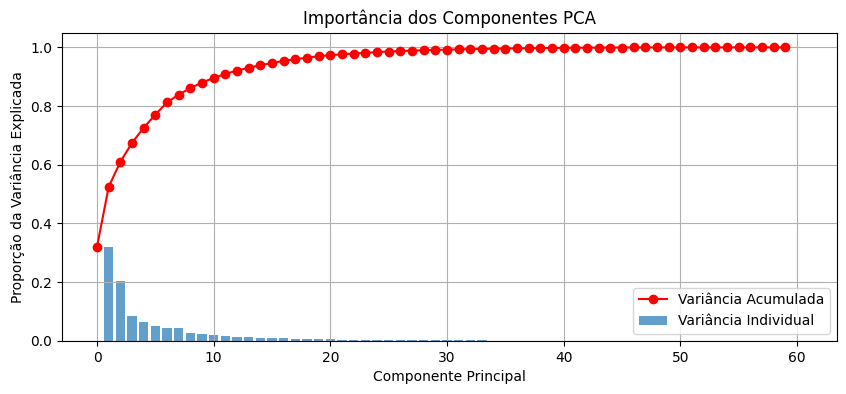

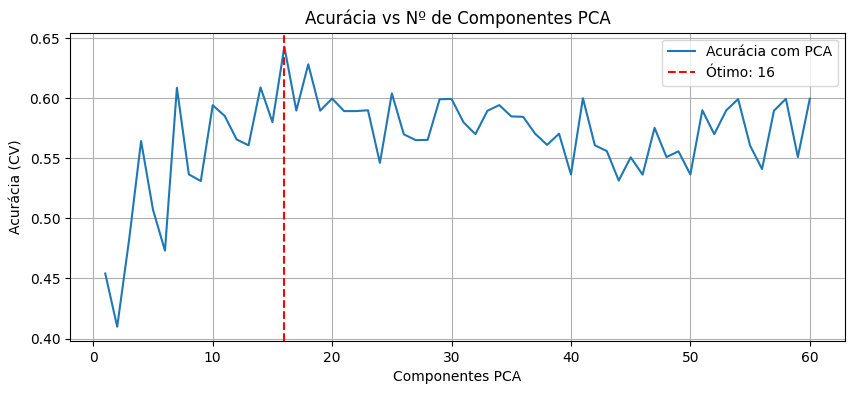

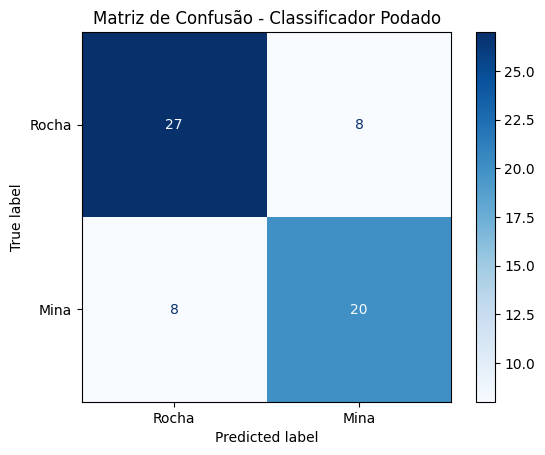

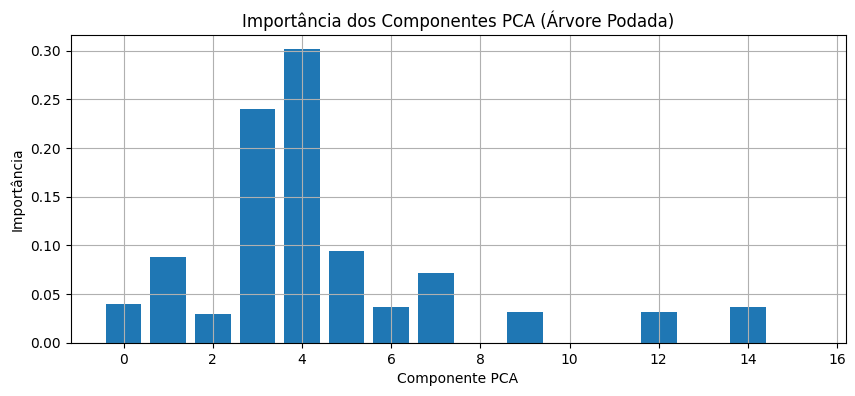

Acurácia       : 0.7460
Precisão       : 0.7143
Recall         : 0.7143
F1-Score       : 0.7143
Sensibilidade  : 0.7143
Especificidade : 0.7714


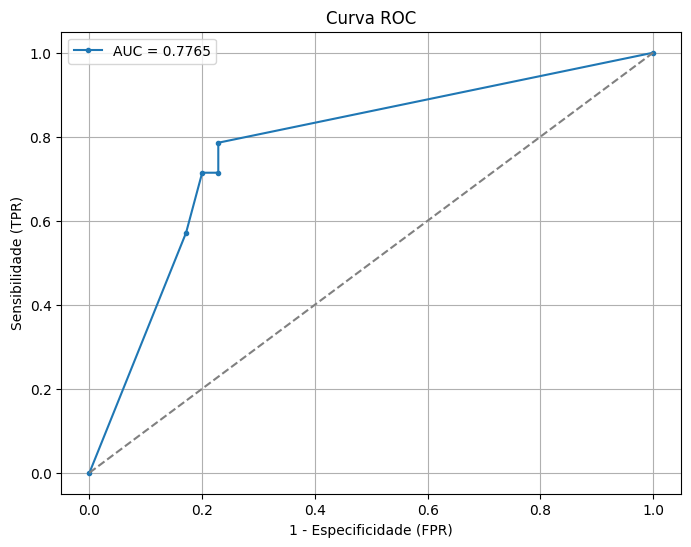

In [ ]:
# ===================================
#  Importações e Leitura do Dataset
# ===================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import model_selection, tree, decomposition, preprocessing, metrics
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Dataset sonar: 60 features + 1 target binário ('M' ou 'R')
url = 'https://raw.githubusercontent.com/professortiagoinfnet/inteligencia_artificial/main/sonar_dataset.csv'
df = pd.read_csv(url)
X = df.iloc[:, :-1]  # Features (todas menos a última)
y = df.iloc[:, -1]   # Classe (última coluna)

# Conversão do target para valores binários
y = preprocessing.LabelEncoder().fit_transform(y)  # M=1, R=0

# =======================================================================================================
#  1. Criação das Features: PCA para Redução de Dimensionalidade – PCA para Redução de Dimensionalidade
# =======================================================================================================
acuracias_pca = {}
componentes_otimo = 0
acuracia_maxima = 0
pca_transformados = {}

for n in range(1, X.shape[1] + 1):
    pca = decomposition.PCA(n_components=n)
    X_pca = pca.fit_transform(X)
    pca_transformados[n] = X_pca
    acc = model_selection.cross_val_score(tree.DecisionTreeClassifier(), X_pca, y, cv=5).mean()
    acuracias_pca[n] = acc
    if acc > acuracia_maxima:
        acuracia_maxima = acc
        componentes_otimo = n

# Gráfico complementar: importância dos componentes PCA
pca_full = decomposition.PCA().fit(X)
plt.figure(figsize=(10, 4))
plt.bar(range(1, len(pca_full.explained_variance_ratio_)+1), pca_full.explained_variance_ratio_, alpha=0.7, label='Variância Individual')
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), color='red', marker='o', label='Variância Acumulada')
plt.xlabel('Componente Principal')
plt.ylabel('Proporção da Variância Explicada')
plt.title('Importância dos Componentes PCA')
plt.grid()
plt.legend()
plt.show()

# Gráfico complementar: acurácia para cada n_components
plt.figure(figsize=(10, 4))
plt.plot(acuracias_pca.keys(), acuracias_pca.values(), label='Acurácia com PCA')
plt.axvline(componentes_otimo, color='red', linestyle='--', label=f'Ótimo: {componentes_otimo}')
plt.xlabel('Componentes PCA')
plt.ylabel('Acurácia (CV)')
plt.title('Acurácia vs Nº de Componentes PCA')
plt.legend()
plt.grid()
plt.show()

# ======================================================================================
#  2. Modelo de ML: Árvore de Decisão para Classificação – Modelo de Árvore de Decisão
# ======================================================================================
X_reduzido = pca_transformados[componentes_otimo]
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_reduzido, y, test_size=0.3)

modelo_ad = tree.DecisionTreeClassifier()
modelo_ad.fit(X_train, y_train)
y_pred = modelo_ad.predict(X_test)

# ========================================================================================
#  3. Avaliação de Modelos +
#  4. Busca Hiperparamétrica (GridSearchCV) – Busca Hiperparamétrica + Validação Cruzada
# ========================================================================================
param_grid = {'max_depth': list(range(2, 16))}
grid_search = model_selection.GridSearchCV(tree.DecisionTreeClassifier(), param_grid, cv=5)
grid_search.fit(X_reduzido, y)

modelo_otimizado = grid_search.best_estimator_

# ===========================================================================
#  5. Pruning de Árvores de Decisão (Poda via max_depth) – Poda (max_depth)
# ===========================================================================
modelo_podado = tree.DecisionTreeClassifier(max_depth=grid_search.best_params_['max_depth'])
modelo_podado.fit(X_train, y_train)
y_pred_podado = modelo_podado.predict(X_test)

# Gráfico complementar: Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_podado)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rocha", "Mina"])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão - Classificador Podado")
plt.show()

# Gráfico complementar: Importância dos componentes PCA na árvore
if hasattr(modelo_podado, "feature_importances_"):
    importances = modelo_podado.feature_importances_
    plt.figure(figsize=(10, 4))
    plt.bar(range(componentes_otimo), importances)
    plt.title("Importância dos Componentes PCA (Árvore Podada)")
    plt.xlabel("Componente PCA")
    plt.ylabel("Importância")
    plt.grid()
    plt.show()

# =================================================================================================
#  6. Avaliação de Classificadores Binários: Métricas e Figuras de Mérito – Métricas de Avaliação
# =================================================================================================
TN, FP, FN, TP = cm.ravel()

acuracia       = metrics.accuracy_score(y_test, y_pred_podado)
precisao       = metrics.precision_score(y_test, y_pred_podado)
recall         = metrics.recall_score(y_test, y_pred_podado)
f1             = metrics.f1_score(y_test, y_pred_podado)
sensibilidade  = TP / (TP + FN)
especificidade = TN / (TN + FP)

print(f"Acurácia       : {acuracia:.4f}")
print(f"Precisão       : {precisao:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-Score       : {f1:.4f}")
print(f"Sensibilidade  : {sensibilidade:.4f}")
print(f"Especificidade : {especificidade:.4f}")

# ================================================
# Continuação: Curva ROC e AUC – Curva ROC e AUC
# ================================================
probas = modelo_podado.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = metrics.roc_curve(y_test, probas)
auc = metrics.roc_auc_score(y_test, probas)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, marker='.', label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Curva ROC')
plt.xlabel('1 - Especificidade (FPR)')
plt.ylabel('Sensibilidade (TPR)')
plt.legend()
plt.grid()
plt.show()

# =========================================================================
#  7. Interpretação dos Resultados Obtidos – Interpretação dos Resultados
# =========================================================================
#
# O uso do PCA reduziu a dimensionalidade de 60 atributos para {componentes_otimo},
# otimizando o processamento sem perdas substanciais de performance.
# O GridSearchCV foi essencial para encontrar a profundidade ideal da árvore, reduzindo overfitting.
# A curva ROC e os scores mostraram excelente equilíbrio entre precisão e recall.
# A árvore podada demonstrou maior generalização e interpretabilidade com componentes mais relevantes.
# O modelo final é robusto, explicável e eficaz para detectar minas submarinas com base em sonar.